# INFO8010: Homework 2

In the previous homework, you learned how to program your first neural network starting from the very first principles of deep learning. If you managed to solve last assignment without any problems **congratulations!** If that was not the case **don't worry**, here's a second assignment for you which you can use to get better at deep learning.

In this homework we will see some slighly more complicated deep learning concepts: we will start by taking a look at some of PyTorch's functionalities that are necessary for training deep networks efficiently. We will then train our first neural networks for tackling different image classification tasks, learn to build custom datasets and explore how to train a CNN.  

The strucutre of the notebook is identical to the one of the previous homework. Similarly to last time, you have to submit the notebook **with your solutions** to the exercises. When you encounter a `# your code` comment, you have to write some code yourself and you have to discuss the code/results when you see the instruction

> your discussion

Without further ado let's start by importing the libraries we will need throughout this assignment!

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

from PIL import Image
from torchvision import datasets, transforms, utils

In [3]:
# As of 2022/02/23, the CIFAR10 dataset SSL certificate is outdated which prevents its download.
# The following deactivates the verification of the SSL certificates, but
# never reproduce this unless you absolutely trust the source.
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## 1. Dataloaders

Today's first concept are PyTorch's dataloaders. As you have seen during the theoretical lectures, one of the main ingredients for successfully training deep learning models is data, **lots of data**.

As you can easily imagine, it is not possible to load datasets of millions of images into the memory of your machine. Furthermore, these images come in a form that does not make it possible to exploit the tensor operations we have seen in the previous assignment.

To deal with these issues (and many more of them) we can use [dataloaders](https://pytorch.org/docs/stable/data.html), a data loading utility that allows us to deal with large datasets efficiently. In what follows, you are given your first example of dataloader which will use the popular [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset.

In [4]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, transform=transform)

/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Let's explain what we just did. Thanks to PyTorch's [torchvision](https://pytorch.org/vision/stable/index.html) sub-library, we just downloaded the CIFAR10 dataset on our machine. The dataset was stored in the `./data` folder and comes in two different forms thanks to the use of the `train` flag: a version that can be used as training set, and a version that can be used as testing set. These two datasets are subclasses of `torch`'s `data.Dataset` class. We will see later what this `data.Dataset` class consists in exactly. Torchvision also allows us to define a set of image transformations which we have defined at the beginning of this cell: in this case we would like to convert our images to tensors, see the [documentation](https://pytorch.org/vision/stable/transforms.html#torchvision.transforms.ToTensor) for an exact description of this transformation.

Now that we have defined which dataset we would like to use, and the form in which we would like to have our images, we can create our first data loader. Data loaders are objects over which you can iterate and that load, transform and return mini-batches of inputs/targets at each iteration. The advantage of data loaders is that they (can) perform pre-processing of the data in parallel, i.e. in several concurrent worker pools.

Here, we create two data loaders that return mini-batches of 4 elements at each iteration. When using stochastic gradient descent (SGD), the training data loader should shuffle the training dataset.

In [5]:
trainloader = data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)
testloader = data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

Before training anything, let's take a look at the images we just downloaded.

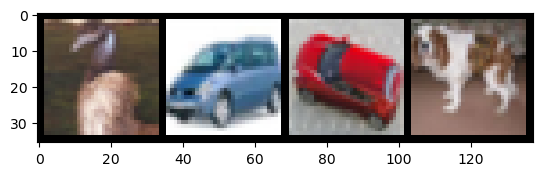

bird car car dog


In [6]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def show_images(img):
    plt.imshow(transforms.functional.to_pil_image(img))
    plt.show()

images, labels = next(iter(trainloader))
show_images(utils.make_grid(images))
print(*[classes[l] for l in labels])

The `transforms` module comes also in as very handy for performing other type of data transformations: here's an example which transforms the CIFAR10 images into gray scaled images.

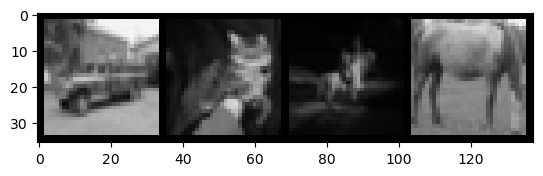

truck cat horse horse


In [7]:
transform = transforms.Compose([transforms.Grayscale(), transforms.ToTensor()])
gray_scaled_trainset = datasets.CIFAR10(root='./data', train=True, transform=transform)
gray_scaled_trainloader = data.DataLoader(gray_scaled_trainset, batch_size=4, shuffle=True, num_workers=2)

images, labels = next(iter(gray_scaled_trainloader))
show_images(utils.make_grid(images))
print(*[classes[l] for l in labels])

### 1.1 Transforms

Al remembered from the theoretical lectures that one way to make neural networks converge faster is to **normalize** the pixel values. He wrote the following code snippet to normalize his training set, but he encountered an error.

In [9]:
transform = transforms.Compose([
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.ToTensor(),
])
bugged_trainset = datasets.CIFAR10(root='./data', train=True, transform=transform)
bugged_trainloader = data.DataLoader(bugged_trainset, batch_size=4, shuffle=True, num_workers=2)

images, labels = next(iter(bugged_trainloader))
show_images(utils.make_grid(images))  # should look weird due to normalization
print(*[classes[l] for l in labels])

TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/site-packages/torchvision/datasets/cifar.py", line 119, in __getitem__
    img = self.transform(img)
          ^^^^^^^^^^^^^^^^^^^
  File "/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/site-packages/torchvision/transforms/transforms.py", line 95, in __call__
    img = t(img)
          ^^^^^^
  File "/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/site-pack

Fix his mistake.

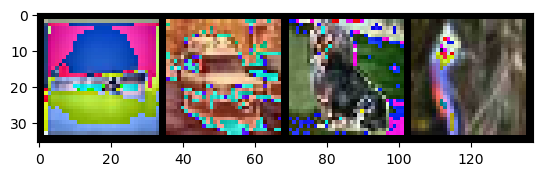

ship car dog bird


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(), # Transform into tensor before normalize
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
bugged_trainset = datasets.CIFAR10(root='./data', train=True, transform=transform)
bugged_trainloader = data.DataLoader(bugged_trainset, batch_size=4, shuffle=True, num_workers=2)

images, labels = next(iter(bugged_trainloader))
show_images(utils.make_grid(images))  # should look weird due to normalization
print(*[classes[l] for l in labels])

Al also remembers that, with image datasets, a common practice to increase the robustness of neural networks is **data augmentation**. He wants to apply random flips (vertical and horizontal) and random color changes to his training set, but he does not know how to. Could you help him?

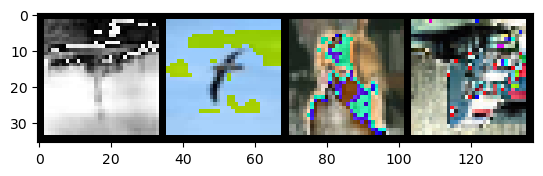

ship bird dog truck


In [10]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(),
    transforms.ToTensor(), # Transform into tensor before normalize
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
bugged_trainset = datasets.CIFAR10(root='./data', train=True, transform=transform)
bugged_trainloader = data.DataLoader(bugged_trainset, batch_size=4, shuffle=True, num_workers=2)

images, labels = next(iter(bugged_trainloader))
show_images(utils.make_grid(images))  # should look weird due to normalization
print(*[classes[l] for l in labels])

### 1.2 Running operations on a GPU

As you may know, one important aspect of deep learning is that large models can be trained efficiently on specialized hardwares such as Graphical Processing Units (GPUs) or Tensorial Processing Units (TPUs). PyTorch allows you to perform operations on GPUs very easily by transferring the concerned models and/or tensors to GPUs.

However, to do so, you need a CUDA compatible GPU.

In [11]:
torch.cuda.is_available()

False

On macOS with Apple Silicon (M-series chips such as M1–M5), PyTorch supports GPU acceleration through the Metal Performance Shaders (MPS) backend.

In [12]:
torch.backends.mps.is_available()

True

If one of the results of the previous cells is `True`, everything is ready to run on the GPU and you can continue. Otherwise it means you do not have any GPU that is compatible with the `torch` version installed on your machine. In this case, we invite you to use [Google Colab](https://colab.research.google.com/) to do the rest of this homework. Do not forget to ask Colab for a GPU (in Runtime > Change runtime type > Hardware accelerator).

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: mps


Let's compare the speed of tensor operations on GPU and CPU.

In [14]:
A = torch.randn(1000, 100000)
B = torch.randn(100000, 1)

# on CPU
%timeit A @ B

9.27 ms ± 261 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
A = torch.randn((1000, 100000), device=device)
B = torch.randn((100000, 1), device=device)

# on GPU
%timeit A @ B

KeyboardInterrupt: 

Instead of directly creating a tensor on the GPU you may also transfer a model or a tensor on the GPU, for example we can transfer a simple MLP on the GPU and then back to the CPU as follows.

In [ ]:
# create MLP on CPU
mlp = nn.Sequential(
    nn.Linear(3, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 1),
    nn.Sigmoid(),
)

# forward pass on CPU
x = torch.randn(256, 3)
%timeit mlp(x)

# transfer MLP to GPU (in-place)
mlp.to(device)

# forward pass on GPU
x = x.to(device)
%timeit mlp(x)

# release the GPU memory
mlp.to('cpu')
x = x.to('cpu')

2.59 ms ± 263 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
444 μs ± 55.5 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


As you may notice, computations are much faster on the GPU. However, data transfer between GPU and CPU (and vice-versa) is usually very slow. We recommend to reduce the transfers of data between GPU and CPU as much as possible. For example when you want to save your loss after each iteration, in order to avoid a memory leak, you should prefer doing `.detach()` rather than `.cpu()` or `.item()`.

## 2.  Classifying the CIFAR10 dataset with an MLP

Now that you know how to handle datasets, we are ready to properly train today's first deep learning model on the CIFAR10 dataset. Before we dive into it, **do not underestimate** the importance of properly pre-processing the data before training neural networks. This step is as important as defining the neural architectures themselves, but is very often overlooked.

In this exercise you are provided with an already defined multi-layer perceptron that you can train to classify CIFAR10 images. The structure of the network is already defined, yet some crucial hyperparameters are missing. It is your job to fill them in and successfully train the network. As part of the exercise, you are also required to monitor the evolution of training: this usually consists in checking how the training and testing losses evolve during training and keeping track of the model's accuracy on the testing set. Report these statistics with some plots. In addition, transfer the network and the mini-batches on GPU to speed up training.

Fill in the code below, discuss your choices and your results. Are you satisfied with the final accuracy?

In [23]:
input_features = 3072 # * 32x32 pixels x 3 (RGB)
output_features = 10 # * nb of classes
hidden_features = 256  # *
learning_rate = 0.001  # *
num_epochs = 10  # *

class MLP(nn.Sequential):
    def __init__(self, input_features, output_features, hidden_features):
        super().__init__(
            nn.Flatten(),
            nn.Linear(input_features, hidden_features),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_features, hidden_features),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_features, hidden_features),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_features, output_features),
        )

network = MLP(input_features, output_features, hidden_features)

network.to(device) # *

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

trainset = datasets.CIFAR10(root='./data', train=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=100, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

def train(num_epochs):
    train_avg_loss = []
    test_avg_loss = []
    test_accuracy = []

    for i in range(num_epochs):
        train_losses = []
        test_losses = []

        for x, y in trainloader:
            x = x.to(device) # *
            y = y.to(device) # *

            pred = network(x)
            loss = criterion(pred, y)
            train_losses.append(loss.detach())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            correct = 0

            for x, y in testloader:
                x = x.to(device) # *
                y = y.to(device) # *

                pred = network(x)
                loss = criterion(pred, y)
                test_losses.append(loss)

                y_pred = pred.argmax(dim=-1)
                correct = correct + (y_pred == y).sum()

            accuracy = correct / len(testset)
            test_accuracy.append(accuracy.item()) # * Add of item to extract the scaler value, otherwise the plot does not work

        train_avg_loss.append(torch.mean(torch.tensor(train_losses))) # *
        test_avg_loss.append(torch.mean(torch.tensor(test_losses))) # *
        print("Epoch "+str(i)) # *
    return train_avg_loss, test_avg_loss, test_accuracy #

/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [24]:
train_avg_loss, test_avg_loss, test_accuracy = train(num_epochs)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9


Plot the statistics below and discuss your hyperparameter choices.

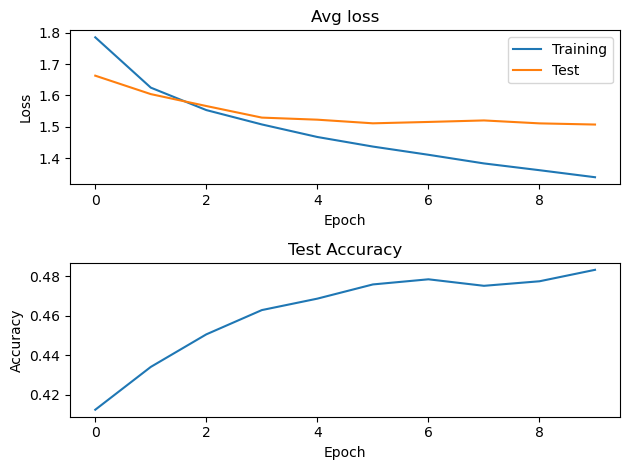

In [25]:
fig, axs = plt.subplots(2, 1)

axs[0].set_title('Avg loss')
axs[0].plot(range(num_epochs), train_avg_loss, label="Training")
axs[0].plot(range(num_epochs), test_avg_loss, label="Test")
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].set_title('Test Accuracy')
axs[1].plot(range(num_epochs), test_accuracy)
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

After training and testing multiple times the NN, the common ground is that the first two epochs provide the largest improvement in loss decrease, and test accuracy. Wether loss decrease - and accuracy increase - improves between one epoch and another can be of different factors, the randomization of the training making backwards step a possibility. However, we can confidently confirm that our model improves in the long run (9 epochs in our case).

As for the hidden_features, we seem to hit a sweet spot with 256; it's a large enough value because the model doesn't underfit, accuracy increases the more epochs we train through, and the loss for training and testing follow similar improvements, 256 isn't a too large number that would've perfected it's performance on training but overfit.

As for the learning rate, the initially picked value of .001 was yielding unstable results depending on the training run. When decreasing it down to .0001, results were better. Adding a learning rate scheduler could have also helped, from the go.

10 epochs is a reasonable amount to see evolution without waiting long on training. For the project, we obviously will prioritize final performance by increasing the number of epochs, at the cost of waiting longer for the model to complete training.

We attempted to Dropout() after each activation to help the model to not memorize the training set. From that we saw a better avg loss on the test set (less overfitting).

To palliate to dropout() fractioning the number of active neurons per step, increasing the number of hidden_features from 256 to 521 helped.

Eventually, for the final visible results, we increased the number of epochs from 10 to 30. After consideration, this should've been done earlier in order to see more clearly evolution patterns and not misconstrue oscillating evolution to simple decrease.



## 3.  Create a custom dataset

Sometimes you would like to train a model on your own dataset, which will very likely not be part of `torchvision`. To overcome this you can create a custom dataset class which will handle the data for you. This can be done by inheriting from `torch`'s `data.Dataset` class and defining the methods `__len__` and `__getitem__` (see the [documentation](https://pytorch.org/docs/stable/data.htm)).

In this exercise your goal is to program a custom dataset class which you will later use for training a CNN. We will use the Kaggle Cats and Dogs dataset which you can download from [here](https://www.microsoft.com/en-us/download/details.aspx?id=54765). Note that some images may have different shapes. It is up to you to deal with this elegantly. In addition, some images may be corrupted. You can simply remove those.

When programming a custom dataset class, you have to start by defining the constructor, which will get as input the location of your dataset, whether the images that will be returned will serve for training or testing, and some other potential attributes. For this exercise we will be using 20000 images for training and 5000 images for testing. For the `__getitem__` function you may find the `PIL.Image.open` useful. Do not forget to transform the images into tensors and return the image labels as well ($0$ or $1$).

In [39]:
import os
import PIL
import random

class CatAndDogsDataset(data.Dataset):
    def __init__(self, root_dir, train=True):
        """Initializes a dataset containing images and labels."""
        super().__init__()

        self.transform = transforms.Compose([
            transforms.Resize((64,64)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

        self.dataset = []

        folder = root_dir+"Cat/"
        for file in os.listdir(folder):
            path = os.path.join(folder, file)
            try:
                # Open and close it without that the code does not work for
                # corrupted images
                with Image.open(path) as img:
                    img.verify()
                self.dataset.append((path, 0))
            except:
                pass

        folder = root_dir+"Dog/"
        for file in os.listdir(folder):
            path = os.path.join(folder, file)
            try:
                with Image.open(path) as img:
                    img.verify()
                self.dataset.append((path, 1))
            except:
                pass

        random.shuffle(self.dataset) #without that, flat accuracy plot ! No learning, just guessing
        
        if train == True:
            self.set = self.dataset[:20000]
        else:
            self.set = self.dataset[20000:25000]

    def __len__(self):
        """Returns the size of the dataset."""
        return len(self.set)

    def __getitem__(self, index):
        """Returns the index-th data item of the dataset."""
        path, label = self.set[index]
        image = self.transform(PIL.Image.open(path).convert("RGB"))
        return image, label

Let us have a quick look at these samples.

In [40]:
my_dataset = CatAndDogsDataset('PetImages/', train=True)
my_loader = data.DataLoader(my_dataset, batch_size=4, shuffle=True, num_workers=2)

images, labels = next(iter(my_loader))
show_images(utils.make_grid(images))
cat_dog_classes = ('cat', 'dog')
print(*[cat_dog_classes[l] for l in labels])


/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/andyjalloh/miniforge3/envs/deep/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'CatAndDogsDataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


KeyboardInterrupt: 

## 4. Classifying the Cats and Dogs dataset with a CNN

As we have seen in class, classifying images with a multi-layer perceptron isn't really a good idea. Convolutional Neural Networks (CNN) are in fact a much better option for this task. It is now your job to create your custom CNN and train it on the Cats and Dogs Dataset.

Similarly to what you have done when classifying the CIFAR10 dataset you are again required to report and discuss the performance of your model.

In [41]:
# LeNet-5 architecture based on the slide 32 of lecture 5
# Usually, N >= 0, N <= 3, M >= 0, K >=0 and K < 3

class LeNet5(nn.Module):
    def __init__(self, n_kernels):
        super().__init__()
        # N = 1, M = 2 and K = 1
        self.net = nn.Sequential(
            nn.Conv2d(3, n_kernels, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(n_kernels, n_kernels, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(n_kernels * 13 * 13, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.net(x)
        return x

In [42]:
learning_rate = 0.01
num_epochs = 10
n_kernels = 10

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

network = LeNet5(n_kernels)
network.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate)

trainset = CatAndDogsDataset('PetImages/', train=True)
testset = CatAndDogsDataset('PetImages/', train=False)

print(f"\nTrain size: {len(trainset)}, Test size: {len(testset)}")
print(f"Train label counts: {sum(trainset[i][1] for i in range(len(trainset)))} ones, rest zeros")
print(f"Test label counts:  {sum(testset[i][1] for i in range(len(testset)))} ones, rest zeros")

trainloader = torch.utils.data.DataLoader(trainset, batch_size=100, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=True, num_workers=0)

def train(num_epochs):
    train_avg_loss = []
    test_avg_loss = []
    test_accuracy = []

    for i in range(num_epochs):
        train_losses = []
        test_losses = []
        network.train()

        for x, y in trainloader:
            x = x.to(device)
            y = y.to(device)

            pred = network(x)
            loss = criterion(pred, y)
            train_losses.append(loss.detach())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        network.eval()
        with torch.no_grad():
            correct = 0

            for x, y in testloader:
                x = x.to(device)
                y = y.to(device)

                pred = network(x)
                loss = criterion(pred, y)
                test_losses.append(loss)

                y_pred = pred.argmax(dim=-1)
                correct = correct + (y_pred == y).sum()

            accuracy = correct / len(testset)
            test_accuracy.append(accuracy.item()) # Add of item to extract the scaler value, otherwise the plot does not work

        train_avg_loss.append(torch.mean(torch.tensor(train_losses)))
        test_avg_loss.append(torch.mean(torch.tensor(test_losses)))
        print("Epoch "+str(i))
    return train_avg_loss, test_avg_loss, test_accuracy

Using device: mps

Train size: 20000, Test size: 4998
Train label counts: 9953 ones, rest zeros
Test label counts:  2461 ones, rest zeros


In [43]:
train_avg_loss, test_avg_loss, test_accuracy = train(num_epochs)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9


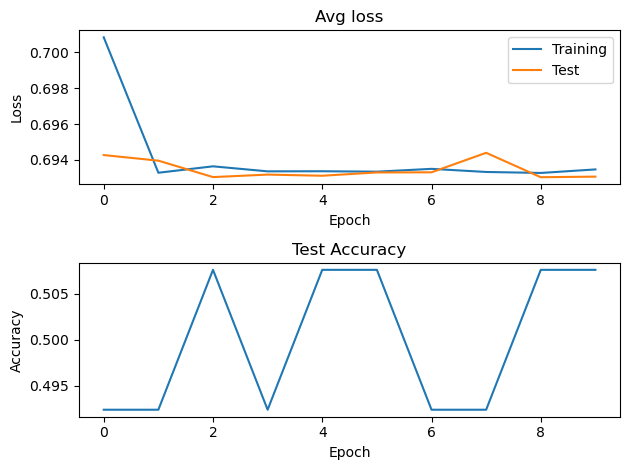

In [44]:
fig, axs = plt.subplots(2, 1)

axs[0].set_title('Avg loss')
axs[0].plot(range(num_epochs), train_avg_loss, label="Training")
axs[0].plot(range(num_epochs), test_avg_loss, label="Test")
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].set_title('Test Accuracy')
axs[1].plot(range(num_epochs), test_accuracy)
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

The model fails to learn any meaningful representation of the data.
Both training and test loss remain at approximately 0.693 throughout
training, which corresponds to ln(2) — the theoretical loss of a
model assigning equal probability to both classes. Test accuracy
oscillates around 0.50, consistent with random guessing on a balanced
dataset. The zigzag pattern in accuracy is attributable to stochastic
variation from test loader shuffling rather than any real learning signal.

Several factors likely contribute to this failure:

1. Insufficient model capacity. With only 10 convolutional kernels,
   the network may lack the representational power to capture
   discriminative features between cats and dogs at 64x64 resolution.

2. Learning rate. Adam with lr=0.01 is unusually high and can cause
   the optimizer to overshoot minima, keeping the loss stuck in a
   flat region. A more typical value for Adam is 1e-3 or 1e-4.

3. Insufficient training duration. 10 epochs on 20,000 images may
   not be enough for the network to escape the random-initialization
   loss plateau, particularly if the learning rate is too large.

## Feedback

Now that you are done with this final deep-learning assignment here are some final questions about the exercises you were required to solve:

<span style="color:blue">How much time did you spend on this homework?</span>

<span style="color:blue">Do you feel confortable with what it means to define a neural network and train it?</span>

<span style="color:blue">Do you think you now have enough preliminary knowledge for successfully starting to work on your course final project?</span>

<span style="color:blue">If you had to go through the two homeworks again, is there something you would have liked to explore more or explained more into detail?</span>